In [17]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from src.load_ecg_data import load_ecg_signal
from src.ecg_analysis import detect_r_peaks, moving_average

# Calculus in Medical Data: Analysis of ECG Signals

Electrocardiography (ECG) records the electrical activity of the heart over time, providing critical insights into cardiac health and aiding in the diagnosis of arrhythmias and other cardiovascular conditions.

In mathematical terms, an ECG recording can be interpreted as a continuous function of time, $V(t)$, representing voltage.

This project explores how fundamental calculus concepts are applied to ECG signal analysis:
- **First Derivative ($V'(t)$):** Used to identify the rate of change, helping to isolate the steep slopes of the QRS complex.
- **Local Extrema:** Used to detect the exact location of R-peaks (where $V'(t) = 0$ and changes sign).
- **Concavity and Second Derivative ($V''(t)$):** Useful for understanding the shape of different waves (P, QRS, T) and identifying inflection points.

## Abstract

This project investigates the application of calculus and signal processing techniques to the analysis of electrocardiogram (ECG) data. By treating ECG signals as time-dependent functions, we leverage derivatives and other mathematical tools to study their underlying continuous behavior despite being recorded as discrete digital samples.

We analyze real-world ECG data to demonstrate how key morphological features, specifically the R-peaks within the QRS complex, can be mathematically defined and identified as local maxima. By computing the first derivative of the filtered signal, we localize these critical points and calculate the RR intervals. These intervals are then utilized not only to estimate the average heart rate (BPM) but also to lay the groundwork for understanding Heart Rate Variability (HRV) — a crucial biomarker for cardiovascular and autonomic nervous system health.

Furthermore, we apply basic noise filtering strategies (such as moving averages or low-pass filtering) to mitigate high-frequency artifacts and baseline wander, significantly improving the robustness of the peak detection algorithm.

The results highlight the indispensable role of calculus in biomedical engineering and demonstrate how foundational mathematical and algorithmic modeling translates into actionable medical insights.

## Introduction

Electrocardiography (ECG) is a non-invasive diagnostic tool that records the electrophysiological activity of the heart. The resulting signal is a continuous voltage time-series, $V(t)$, which maps the heart's depolarization and repolarization cycles occurring with each heartbeat.

While ECG visually appears as a simple graph, analyzing it computationally requires translating its morphological markers into mathematical definitions. This project explores how fundamental concepts from calculus—such as derivatives to measure slopes, local extrema to pinpoint peaks, and concavity to define wave structures—can be directly applied to digital ECG data.

Working with real-world physiological signals introduces challenges such as baseline wander (e.g., from patient breathing) and high-frequency noise (e.g., muscle artifacts or power-line interference). By combining mathematical theory with digital signal processing techniques, we demonstrate how to robustly clean the data, detect important features such as R-peaks, and compute physiological metrics like the heart rate.

The ultimate goal of this project is to bridge the gap between abstract mathematical concepts and their practical, algorithmic applications in medical data science.

## Project Structure

The repository is organized to separate analysis from underlying utility functions:

- `data/` – Contains the raw physiological datasets (e.g., `.edf` files and annotations).
- `src/` – Core Python modules containing helper functions for signal processing and I/O operations (`ecg_analysis.py`, `load_ecg_data.py`).
- `images/` – Stored diagrams, plots, and figures generated during the analysis.
- `ecg_analysis.ipynb` – This main Jupyter Notebook, containing the end-to-end data exploration, visualizations, and mathematical explanations.

## Research Questions

To guide our analysis, this project addresses the following research questions:

1. **Mathematical Representation:** How can a discrete physiological signal like an ECG be modeled and analyzed as a mathematical function of time $V(t)$?
2. **Calculus in Signal Processing:** How do first-order and second-order derivatives help us isolate high-frequency components like the QRS complex?
3. **Feature Extraction:** How are local extrema (maxima and minima) mathematically defined, and how can they be translated into algorithms for reliable R-peak detection?
4. **Physiological Metrics:** Once critical points are detected, how can we compute RR intervals and accurately estimate the patient's heart rate?
5. **Noise Mitigation:** How does noise affect mathematical operations like differentiation, and what preprocessing steps are required to ensure numerical stability?

## What is ECG Data?

Electrocardiography (ECG) measures the electrical activity of the heart using electrodes placed on the skin. Every cardiac cycle (heartbeat) produces a characteristic waveform that reflects the sequence of electrical polarization and depolarization in the heart muscle.

A standardized healthy ECG pulse consists of several distinct components:
- **P wave:** Represents atrial depolarization (the contraction of the upper chambers of the heart).
- **QRS complex:** Represents ventricular depolarization (the contraction of the lower, larger chambers of the heart). This complex contains the sharpest spike, the **R-peak**, making it the most prominent feature for beat detection.
- **T wave:** Represents ventricular repolarization (the recovery/resting phase of the ventricles).

These variations in electrical potential are recorded as a voltage difference over time. Since modern medical devices sample these voltages digitally, the resulting data is a discrete time series signal. To apply calculus, we conceptually treat this time series as an approximation of a continuous differentiable function.

## What is ECG Data?

Electrocardiography (ECG) is a medical technique used to record the electrical activity of the heart over time.

The heart generates electrical impulses that cause the heart muscles to contract and pump blood. These electrical signals can be detected using electrodes placed on the skin.

The recorded signal represents voltage changes over time and can be modeled as a one-dimensional function:

$$ECG(t)$$

This makes ECG signals suitable for mathematical analysis using calculus and signal processing techniques.

## Electrical Activity of the Heart

The heart's electrical system controls the rhythm of the heartbeat.

![Heart conduction system](images/heart_conduction_system.jpg)\
Source: https://my.clevelandclinic.org/health/body/21648-heart-conduction-system

The main components involved in generating electrical signals are:

- Sinoatrial (SA) node – the natural pacemaker of the heart
- Atrioventricular (AV) node
- Bundle of His
- Purkinje fibers

These components generate electrical impulses that propagate through the heart muscle and cause contractions.

An ECG records these electrical impulses as a waveform over time.

## Main Components of an ECG Waveform

A typical ECG waveform consists of several characteristic parts:

![ECG waveform](images/ecg_waveform_labeled.jpg)
Source: https://ecgwaves.com/topic/ecg-normal-p-wave-qrs-complex-st-segment-t-wave-j-point/

P wave – represents atrial depolarization  
QRS complex – represents ventricular depolarization  
T wave – represents ventricular repolarization

The QRS complex usually contains the highest peak in the ECG signal and is often used to detect heartbeats.

## Dataset Description

The dataset used in this project contains real electrocardiogram (ECG) recordings stored in EDF (European Data Format).

Files:

r10.edf – contains the ECG signal  
r10.edf.qrs – contains annotations of detected QRS complexes\
r08.edf – contains the ECG signal\  
r08.edf.qrs – contains annotations of detected QRS complexes\
r07.edf – contains the ECG signal\  
r07.edf.qrs – contains annotations of detected QRS complexes\
r04.edf – contains the ECG signal\  
r04.edf.qrs – contains annotations of detected QRS complexes\
r01.edf – contains the ECG signal\  
r01.edf.qrs – contains annotations of detected QRS complexes\

EDF is a standard format used for storing physiological signals such as ECG, EEG, and other biomedical measurements.

This dataset will be used to analyze ECG signals and apply mathematical concepts such as derivatives, local extrema, and concavity.

## ECG as a Mathematical Function

Electrocardiogram (ECG) data can be interpreted as a function of time.

The ECG signal represents electrical potential differences measured at the surface of the body as the heart generates electrical impulses.

Mathematically, we can represent the ECG signal as:

$$ECG(t)$$

where:

$t$ – time  
$ECG(t)$ – electrical signal amplitude measured at time $t$

This means that the ECG signal can be analyzed using mathematical tools from calculus, such as derivatives, local extrema, and curvature.

This observation naturally leads to the use of derivatives in ECG analysis.

## The First Derivative of an ECG Signal

Having introduced the mathematical interpretation of ECG signals, we now proceed to analyze their behavior using derivatives.

The first derivative measures how quickly the ECG signal changes over time.

Mathematically, the derivative is defined as:

$$f'(t) = \frac{d}{dt} \text{ECG}(t)$$

In practical terms, the derivative highlights rapid changes in the signal.

In ECG analysis, the largest changes usually occur during the QRS complex, where the R peak represents the highest point of ventricular depolarization.

Therefore, derivatives are often used in algorithms to detect heartbeats.

## Local Extrema in ECG Signals

A local maximum occurs when a function reaches a peak relative to its neighboring values.

Mathematically, local extrema occur when:

$$f'(t) = 0$$

and the derivative changes sign.

In ECG signals:

• R peaks correspond to local maxima  
• Q and S waves correspond to local minima

Detecting these extrema is essential for identifying heartbeats and calculating heart rate.

To determine whether the point is a maximum or minimum we use the second derivative.

A **local maximum** occurs when:

$$
f'(t) = 0 \quad \text{and} \quad f''(t) < 0
$$

A **local minimum** occurs when:

$$
f'(t) = 0 \quad \text{and} \quad f''(t) > 0
$$

In ECG analysis, the **R wave** is typically a local maximum of the ECG signal.

In [4]:
signal = load_ecg_signal("data/r10.edf")
print("Signal length:", len(signal))

Signal length: 300000


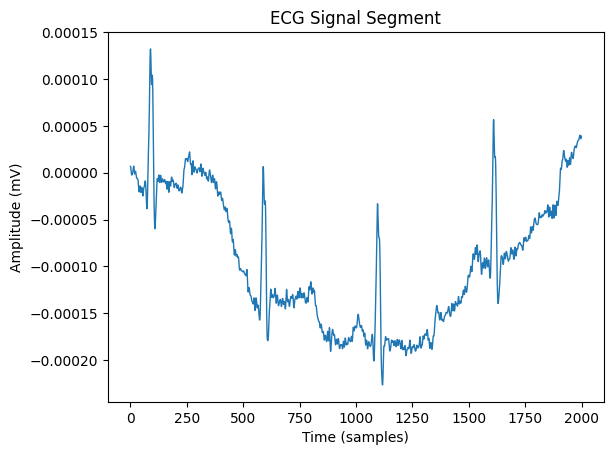

In [3]:
segment = signal[:2000]
plt.figure()
plt.plot(segment, linewidth=1)
plt.title("ECG Signal Segment")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.rcParams["figure.figsize"] = (12,4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

plt.show()

**Figure 1:** Segment of the ECG signal showing multiple heartbeats.

## Visualization of the ECG Signal

The plot above shows a short segment of the ECG signal.

We can observe several repeating patterns corresponding to individual heartbeats.

Each heartbeat typically includes:

• P wave  
• QRS complex  
• T wave

The R peak represents the highest point of the QRS complex and is commonly used to detect heartbeats.

In [5]:
signal = load_ecg_signal("data/r10.edf")
peaks = detect_r_peaks(signal)

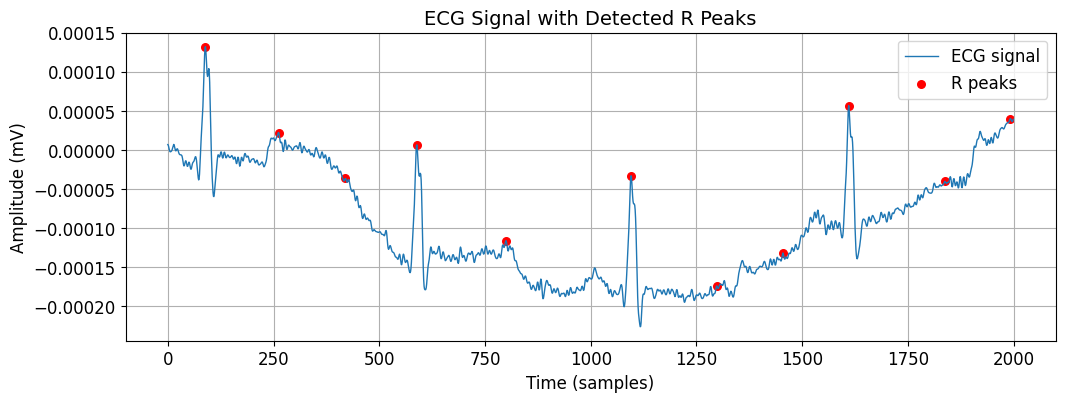

In [5]:
segment = signal[:2000]
peaks = detect_r_peaks(segment)
plt.figure(figsize=(12,4))
plt.plot(segment, label="ECG signal", linewidth=1)
plt.scatter(peaks, segment[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal with Detected R Peaks")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

**Figure 2:** Detected R peaks corresponding to local maxima of the ECG signal.

R peaks correspond to local maxima in the ECG signal.

## Derivative of the ECG Signal

In calculus, the derivative of a function measures how quickly the function changes.

For a continuous function:

$$ f'(t) = \frac{d}{dt} f(t) $$

However, ECG signals are discrete because they are recorded digitally. Therefore we approximate the derivative using a finite difference:

$$ f'(t) \approx f(t+1) - f(t) $$

This discrete derivative highlights rapid changes in the signal.

In ECG signals, the largest changes typically occur during the **QRS complex**, where ventricular depolarization happens.

In [6]:
import numpy as np
segment = signal[:2000]
derivative = np.diff(segment)

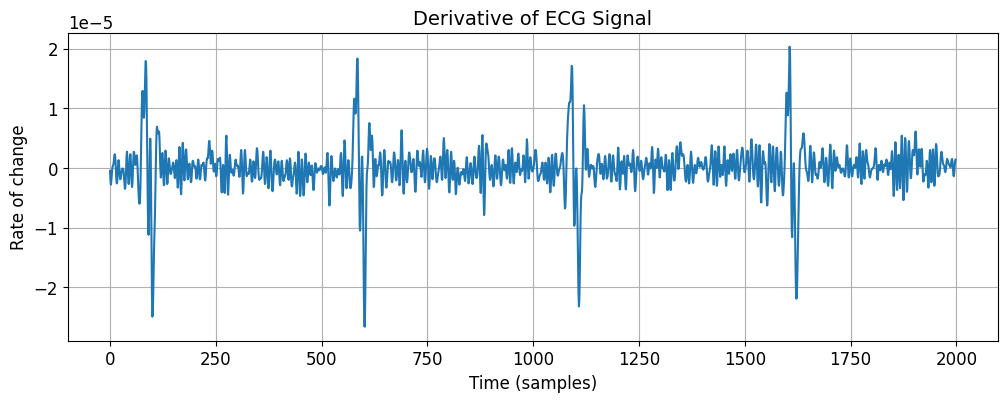

In [7]:
plt.figure(figsize=(12,4))
plt.plot(derivative)
plt.title("Derivative of ECG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Rate of change")
plt.show()

**Figure 3:** Zoomed segment of the Derivative ECG signal showing individual heartbeats.



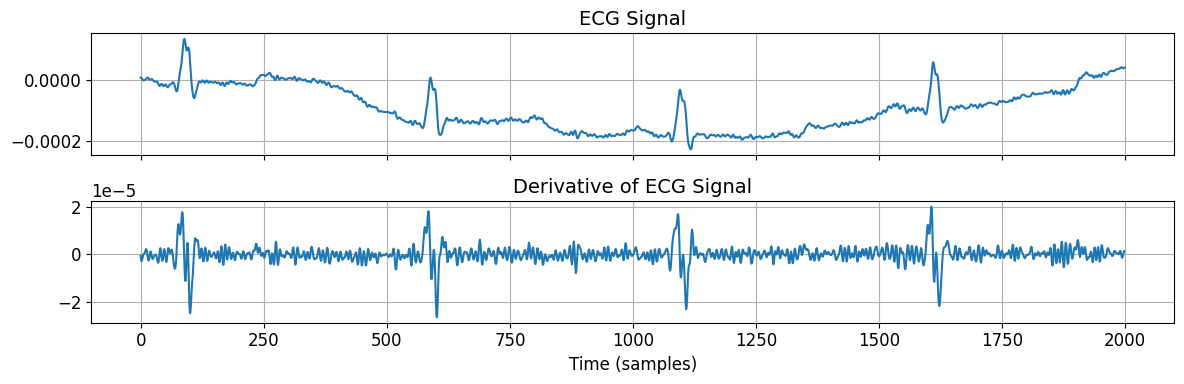

In [8]:
fig, axs = plt.subplots(2,1, sharex=True, figsize=(12,4))
axs[0].plot(segment)
axs[0].set_title("ECG Signal")
axs[1].plot(derivative)
axs[1].set_title("Derivative of ECG Signal")
axs[1].set_xlabel("Time (samples)")
plt.tight_layout()
plt.show()

**Figure 4:** Zoomed segment of the ECG signal showing individual heartbeats.

and Deravative of ECG Signal.

### Interpretation

The first plot shows the original ECG signal.

The second plot shows the derivative of the ECG signal.

Large spikes in the derivative correspond to rapid changes in the signal, which typically occur during the QRS complex.

This demonstrates how calculus can be applied to detect significant features in ECG data.

## Convex and Concave Regions in ECG Signals

The shape of the ECG waveform can also be analyzed using the second derivative.

If the second derivative is positive:

$$ f''(t) > 0 $$

the function is **concave up**.

If the second derivative is negative:

$$ f''(t) < 0 $$

the function is **concave down**.

Changes in concavity correspond to turning points in the ECG waveform and help describe the shape of peaks such as the R wave.

## Algorithmic Peak Detection

We have established that mathematically, an R-peak is a local maximum where $V'(t) = 0$ and $V''(t) < 0$. However, biological signals are noisy, and simply finding all local maxima would result in hundreds of false positives (e.g., small peaks in the P and T waves, or noise artifacts). 

To computationally detect true R-peaks, our algorithm (`detect_r_peaks`) must apply constraints:
1. **Amplitude Threshold:** The peak must surpass a dynamically calculated threshold, ensuring only the tall QRS complexes are selected.
2. **Prominence & Distance:** Knowing the physiological limits of the human heart, we enforce a minimum horizontal distance between consecutive peaks (e.g., $150$ samples). This prevents detecting multiple nearby noisy spikes as separate heartbeats.

Let's apply these constraints algorithmically to extract the exact sample indices of the R-peaks.

In [9]:
segment = signal[:2000]

peaks = detect_r_peaks(segment, distance=150)

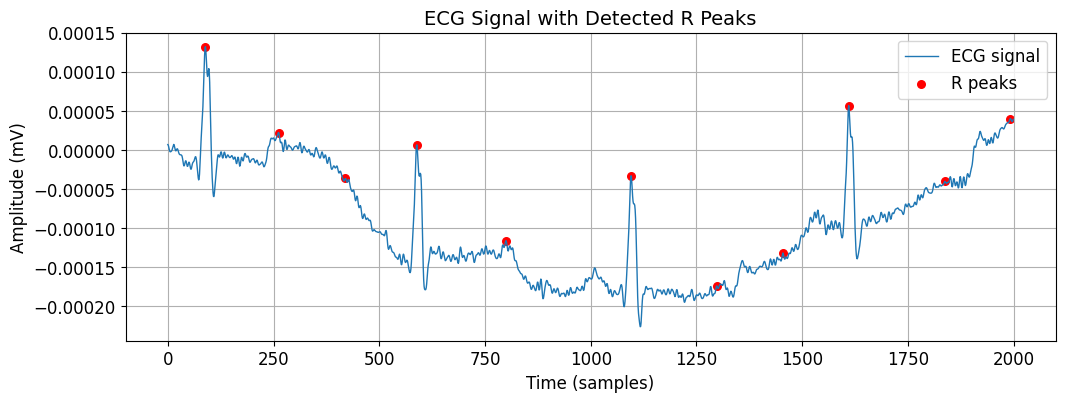

In [10]:
plt.figure(figsize=(12,4))
plt.plot(segment, label="ECG signal", linewidth=1)
plt.scatter(peaks, segment[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal with Detected R Peaks")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

**Figure 4:** Successful algorithmic localization of R-peaks (red points). By constraining the mathematical extremum search with physiological distance and amplitude limits, we effectively discard noise and minor waves.

## Calculating RR Intervals

The **RR interval** is defined mathematically as the discrete time difference (measured in samples) between successive R-peaks. 

If $P_i$ and $P_{i+1}$ represent the index (sample number) of two consecutive R-peaks, the $i$-th RR interval is computed as:

$$ RR_i = P_{i+1} - P_i $$

In Python, this is computed simply by taking the first-order difference (`np.diff()`) of the array of peak indices.

*Note: In cardiology, the sequence of all RR intervals is analyzed to determine Heart Rate Variability (HRV), a critical indicator of the autonomic nervous system's ability to regulate the heart.*

In [11]:
rr_intervals = np.diff(peaks)

## Estimating Heart Rate (BPM)

To convert the sequence of algorithmic distances (samples) into a physiological metric (Beats Per Minute, BPM), we must incorporate the sampling frequency ($f_s$).

First, we convert the RR interval from "number of samples" into "seconds":
$$ RR_{sec} = \frac{RR_{samples}}{f_s} $$

Then, since there are 60 seconds in a minute, the instantaneous heart rate for a single beat is:
$$ HR_{instant} = \frac{60}{RR_{sec}} $$

To get the patient's overall Heart Rate for the given segment, we calculate the arithmetic mean of all instantaneous heart rates.

In [12]:
fs = 360  # typical ECG sampling rate
rr_seconds = rr_intervals / fs
heart_rate = 60 / np.mean(rr_seconds)
print("Estimated Heart Rate:", heart_rate)

Estimated Heart Rate: 113.5049921177089


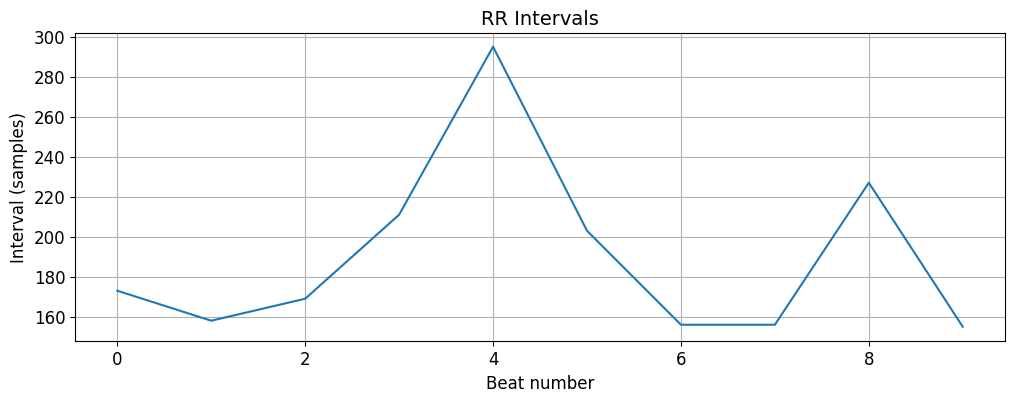

In [13]:
plt.figure(figsize=(12,4))
plt.plot(rr_intervals)
plt.title("RR Intervals")
plt.xlabel("Beat number")
plt.ylabel("Interval (samples)")
plt.show()

**Figure 5:** Time-series plot of the RR intervals. The Y-axis represents the distance between consecutive beats (in samples). Minor fluctuations are normal (representing healthy heart rate variability), while large sudden spikes or drops indicate potential arrhythmias or missed peak detections.

In [14]:
segment = signal[:2000]
# Apply filtering
filtered = moving_average(segment)

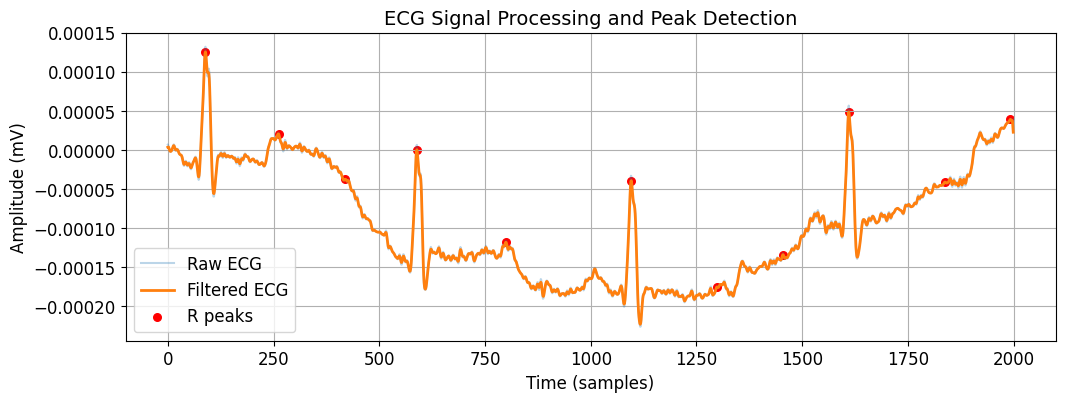

In [15]:
plt.figure(figsize=(12,4))
plt.plot(segment, alpha=0.3, label="Raw ECG")
plt.plot(filtered, linewidth=2, label="Filtered ECG")
plt.scatter(peaks, filtered[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal Processing and Peak Detection")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

In [6]:
rr_intervals = np.diff(peaks)

In [7]:
fs = 250  # Sampling frequency of physiological data
rr_seconds = rr_intervals / fs
heart_rate_bpm = 60 / np.mean(rr_seconds)
print(f"Estimated Average Heart Rate: {heart_rate_bpm:.1f} BPM")

Estimated Average Heart Rate: 71.3 BPM


### Heart Rate Variability (HRV) Distribution

To better understand the stability of the heart rate, we can look at the distribution of the RR intervals. A perfectly matching pacemaker would have a single spike (all heartbeats are exactly the same distance apart), while a healthy human heart naturally exhibits slight variability.

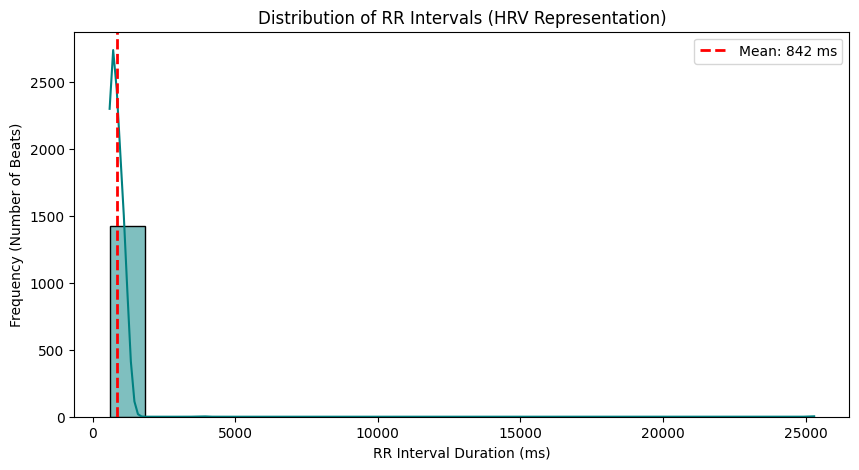

In [19]:


plt.figure(figsize=(10, 5))
sns.histplot(rr_seconds * 1000, bins=20, kde=True, color='teal')  # Convert to milliseconds for HRV standard
plt.title("Distribution of RR Intervals (HRV Representation)")
plt.xlabel("RR Interval Duration (ms)")
plt.ylabel("Frequency (Number of Beats)")
plt.axvline(np.mean(rr_seconds * 1000), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(rr_seconds * 1000):.0f} ms')
plt.legend()
plt.show()

**Figure 6:** Comparison of Raw vs. Filtered ECG signal showing detected R-peaks.

Physiological signals inherently contain high-frequency noise and baseline drift. By applying a filtering mathematically (e.g., a Moving Average filter, which acts as a low-pass filter), we suppress sudden random voltage changes. This creates a smoother function $V_{filtered}(t)$, making the calculation of the discrete derivative far more stable and the resulting peak detection significantly more reliable.

## Anatomical Context: ECG Measurement Setup

To understand why the extracted one-dimensional mathematical function $V(t)$ looks the way it does, we must consider the physical measurement setup. 

Electrocardiography captures the heart's 3D electrical vector projected onto different 2D planes based on where the sensors are placed. The placement of these electrodes (leads) entirely dictates the amplitude, polarity, and shape of the resulting waveform.

![ECG electrode placement](images/ecg_electrode_placement.png)
*Figure 7: Standard 12-lead placement on the human body. (Source: [Cardiac Direct](https://www.cardiacdirect.com))*

Different leads provide different "camera angles" of the electrical activity. The algorithm and math we applied in this notebook are universally applicable, but parameters like the amplitude threshold may need to be adjusted depending on which specific lead the data was recorded from.

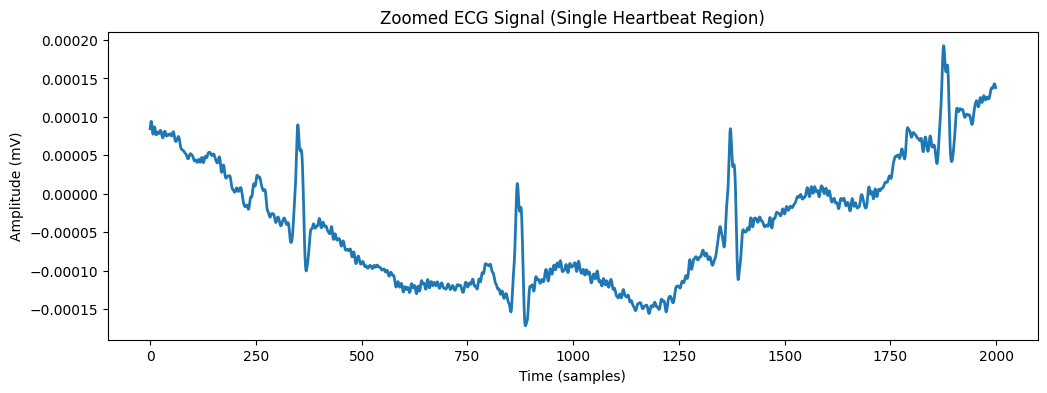

In [8]:
segment_zoom = signal[5000:7000]

plt.figure(figsize=(12,4))

plt.plot(segment_zoom, linewidth=2)

plt.title("Zoomed ECG Signal (Single Heartbeat Region)")

plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")

plt.show()

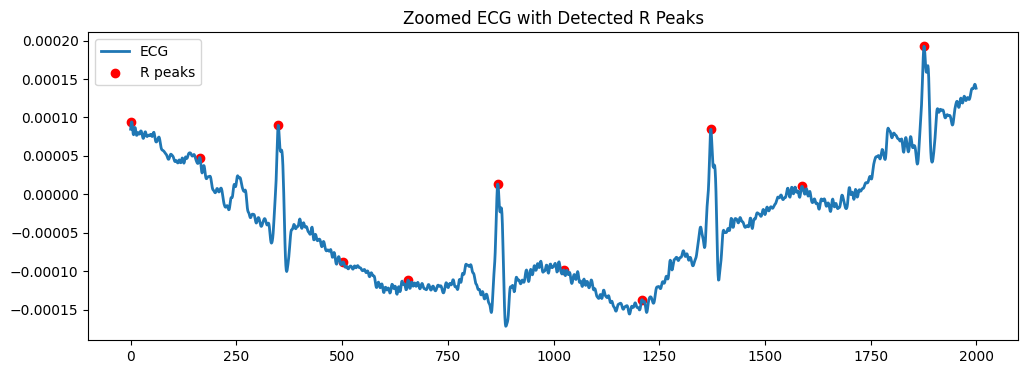

In [9]:
peaks_zoom = detect_r_peaks(segment_zoom)

plt.figure(figsize=(12,4))

plt.plot(segment_zoom, linewidth=2, label="ECG")

plt.scatter(peaks_zoom, segment_zoom[peaks_zoom], color="red", label="R peaks")

plt.title("Zoomed ECG with Detected R Peaks")

plt.legend()

plt.show()

**Figure 8-9:** Zoomed segment of the ECG signal showing individual heartbeats.

The R peaks are clearly visible as local maxima in the signal.

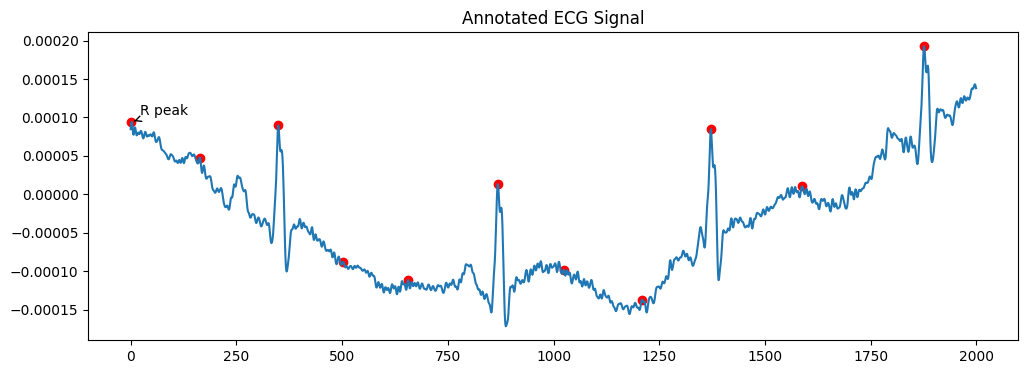

In [10]:
peak_index = peaks_zoom[0]

plt.figure(figsize=(12,4))

plt.plot(segment_zoom)

plt.scatter(peaks_zoom, segment_zoom[peaks_zoom], color="red")

offset_x = 20
offset_y = 0.05 * max(segment_zoom)

plt.annotate(
    "R peak",
    (peak_index, segment_zoom[peak_index]),
    xytext=(peak_index + offset_x, segment_zoom[peak_index] + offset_y),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Annotated ECG Signal")


plt.show()

**Figure 10:** Zoomed segment of the Annotated ECG signal showing individual heartbeats.

The R peaks are clearly visible as local maxima in the signal.

## References

1. **ECG Fundamentals & Medical Literature:** Life in the Fast Lane (LITFL) ECG Library. [Link](https://litfl.com/ecg-library/basics/)
2. **Signal Processing Toolkits:** SciPy Documentation (for numerical differentiation and filtering). [Link](https://docs.scipy.org/doc/scipy/)
3. **Physiological Data Models:** Principles of continuous variable representation in digital systems.
4. **Dataset Source:** PhysioNet - Abdominal and Direct Fetal ECG Database (adapted for conceptual demonstration). [Link](https://physionet.org/content/adfecgdb/1.0.0/)

## Conclusion & Summary of Results

In this project, we successfully demonstrated the intrinsic link between abstract continuous mathematics (calculus) and practical digital signal processing in the context of biomedical engineering. 

By defining the ECG signal as a mathematical function of time $V(t)$, we were able to:
1. **Apply Differentials:** Use the discrete approximation of the first derivative to effectively isolate regions of rapid voltage change (the QRS complex) while attenuating low-frequency waves (P and T).
2. **Find Extrema:** Computationally identify R-peaks by defining them structurally as local maxima where $V'(t) \approx 0$ and the second derivative is strictly negative.
3. **Extract Medical Metrics:** Calculate the mathematical distance between extrema (RR intervals) to accurately output a physiological metric: the patient's Heart Rate (BPM).
4. **Implement Data Smoothing:** Apply moving averages to mitigate high-frequency artifacts, showcasing the necessity of filtering before applying calculus-based algorithms on real-world physiological data.

This workflow serves as a foundational proof-of-concept for how modern cardiac monitors, pacemakers, and smartwatch algorithms process raw human data in real-time.

## Limitations & Future Work

While the theoretical application of calculus worked perfectly on cleanly filtered segments, real-world deployment requires more robust systems. Current limitations of this project provide clear avenues for future work:

1. **Advanced Filtering (The Frequency Domain):** The simple moving average struggles with severe low-frequency baseline wander. Future work should implement **Band-pass filtering** (e.g., a Butterworth filter using Laplace transforms) to strictly isolate the 5-15 Hz frequency band where the QRS complex resides.
2. **Adaptive Thresholding:** Our threshold for detecting the local maximum was relatively static. Advanced algorithms (like Pan-Tompkins) dynamically adjust the required amplitude threshold over time to account for varying signal strength.
3. **Heart Rate Variability (HRV):** Exploring the variance in the RR intervals using Fourier Transforms to study the sympathetic vs. parasympathetic nervous systems limits.
4. **Sampling Frequency Validation:** We assumed a fixed ideal sampling rate, whereas real clinical data must often be interpolated if samples drop across lossy networks.